In [1]:
library(pracma)
library(glmnet)
library(ggplot2)
library(stats)
library(partykit)
source("Utils.R")

Loading required package: Matrix

Attaching package: ‘Matrix’

The following objects are masked from ‘package:pracma’:

    expm, lu, tril, triu

Loading required package: foreach
Loaded glmnet 2.0-16

Registered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang
Loading required package: grid
Loading required package: libcoin
Loading required package: mvtnorm


In [2]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

StScaler <- import("sklearn.preprocessing", convert = FALSE)$StandardScaler
MMScaler <- import("sklearn.preprocessing", convert = FALSE)$MinMaxScaler

In [3]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y


hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

In [104]:
install.packages("MVN")

also installing the dependencies ‘zip’, ‘tmvnsim’, ‘sp’, ‘openxlsx’, ‘minqa’, ‘nloptr’, ‘RcppEigen’, ‘mnormt’, ‘gsl’, ‘carData’, ‘abind’, ‘pbkrtest’, ‘maptools’, ‘rio’, ‘lme4’, ‘nortest’, ‘moments’, ‘psych’, ‘energy’, ‘car’

Updating HTML index of packages in '.Library'
Making 'packages.html' ... done


In [111]:
library("MVN")

In [121]:
mvn(TRAIN_X, mvnTest= "dh")

Test,E,df,p value,MVN
Doornik-Hansen,NaN,602,NaN,NA
Test,Variable,Statistic,p value,Normality
Anderson-Darling,V1,15.5032,<0.001,NO
Anderson-Darling,V2,15.8690,<0.001,NO
Anderson-Darling,V3,16.0076,<0.001,NO
Anderson-Darling,V4,16.3381,<0.001,NO
Anderson-Darling,V5,17.1351,<0.001,NO
Anderson-Darling,V6,17.4002,<0.001,NO
Anderson-Darling,V7,18.6740,<0.001,NO
Anderson-Darling,V8,20.0535,<0.001,NO


In [125]:
TRAIN_X[, 1]

[1] 160

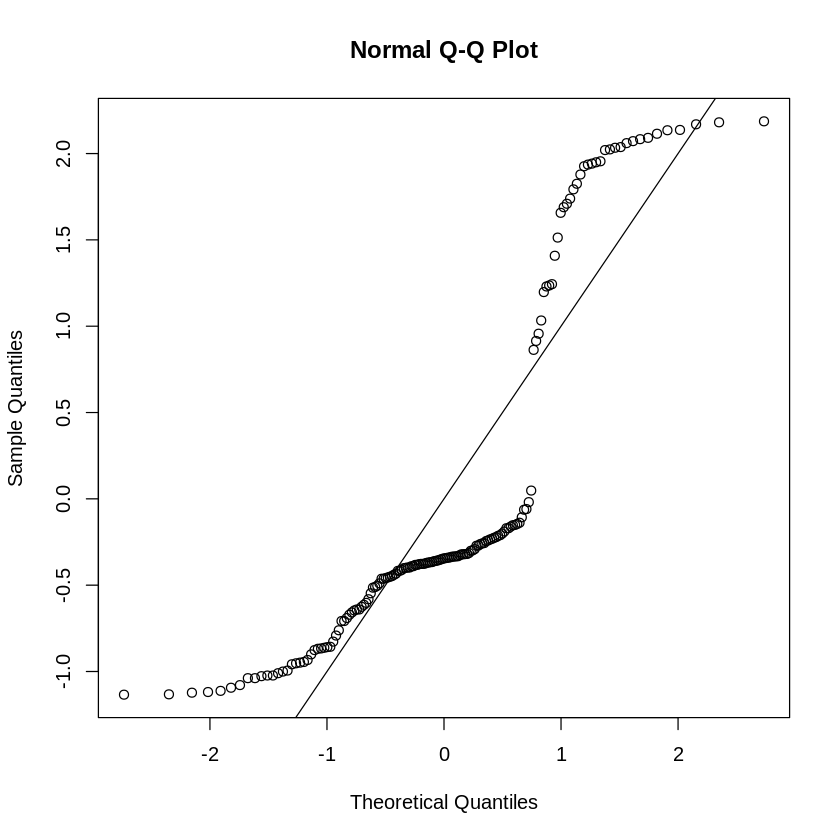

In [138]:
qqnorm(scale(TRAIN_X)[, 1]) 
abline(0,1)

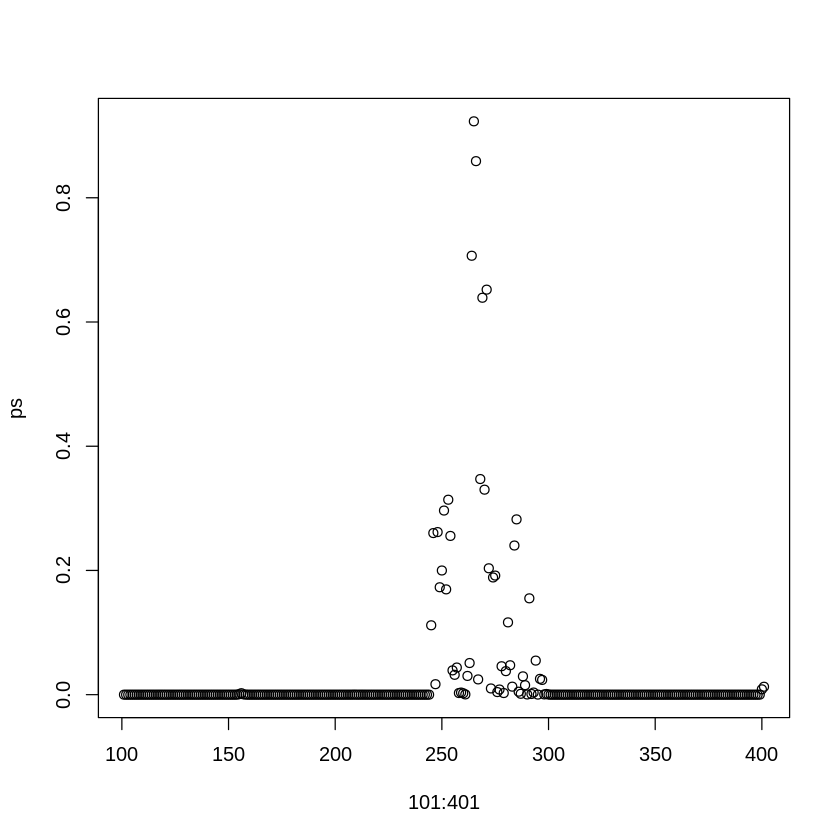

In [132]:
X <- scale(TRAIN_X)
ps <- c()
for (i in 1:301) {
    ps <- c(ps, shapiro.test(X[, i])$p)
}
plot(x=101:401, y= ps)

In [100]:
shapiro.test(TRAIN_X[, 1])


	Shapiro-Wilk normality test

data:  TRAIN_X[, 1]
W = 0.77884, p-value = 2.873e-14


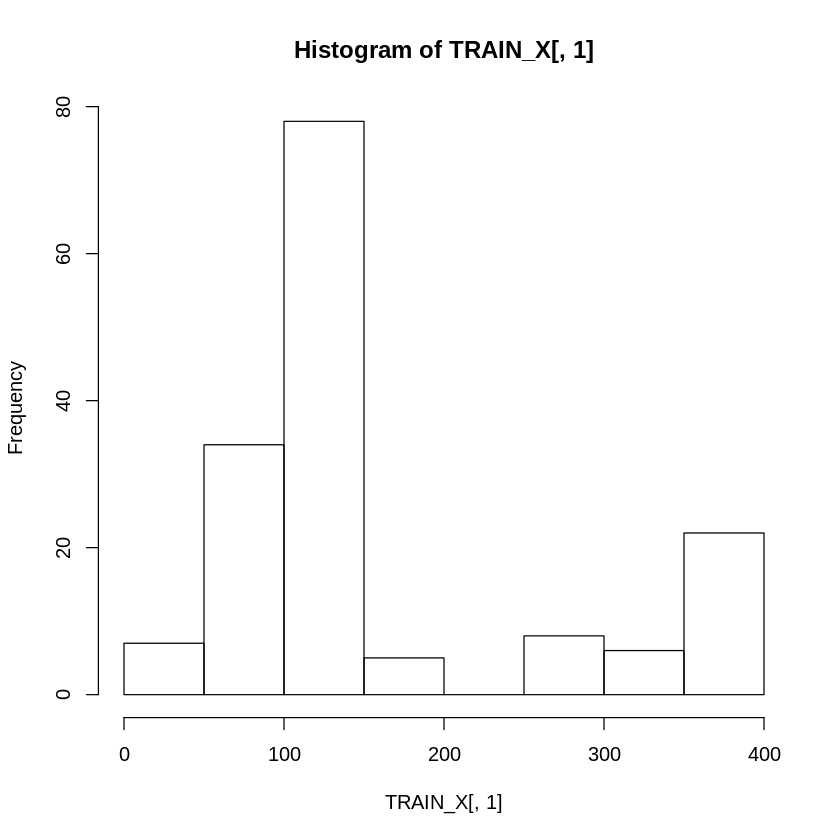

In [96]:
hist(TRAIN_X[, 1])

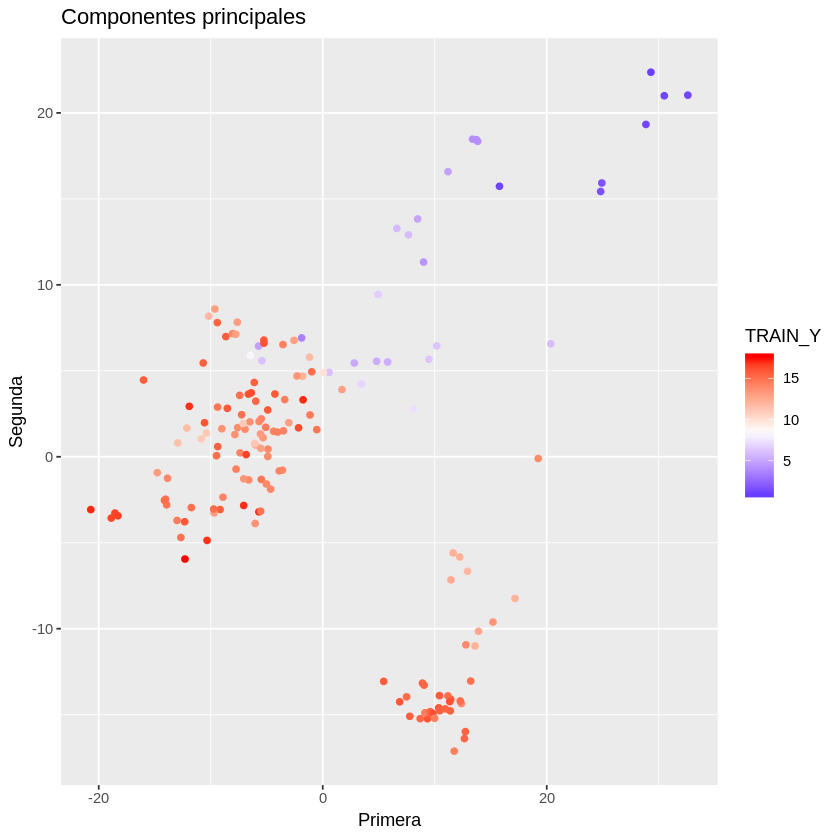

In [88]:
x <- scale(TRAIN_X)
s<-cov(x) #todas positivas, como podíamos observar en el gráfico
e<-eigen(s)
gamma<-e$vectors
lambda<-e$values
xraya<-apply(x,2,mean)
v<-t(gamma)%*%(t(x)-xraya)

#ahora si podemos observar graficamente que sucede con los datos

sp2<-ggplot() + geom_point(aes(x=v[1,], y=v[2,], color=TRAIN_Y))
mid<-mean(TRAIN_Y)
sp2+scale_color_gradient2(midpoint=8.5, low="blue", mid="white",
    high="red") + labs(title="Componentes principales", y="Segunda", x="Primera")

In [89]:
var_explicada<-lambda/sum(lambda)
Comp<-paste("CP", 1:301, sep= "")
Proporcion_explicada<-rbind(Comp,round(var_explicada,4))
Proporcion_explicada

Comp,CP1,CP2,CP3,CP4,CP5,CP6,CP7,CP8,CP9,CP10,...,CP292,CP293,CP294,CP295,CP296,CP297,CP298,CP299,CP300,CP301
,0.4004,0.26,0.1812,0.0608,0.0257,0.0138,0.0058,0.0039,0.0035,0.0017,...,0,0,0,0,0,0,0,0,0,0


Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, c

“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning me

“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning message in apply(height, 2L, cumsum):
“NAs introduced by coercion”Warning me

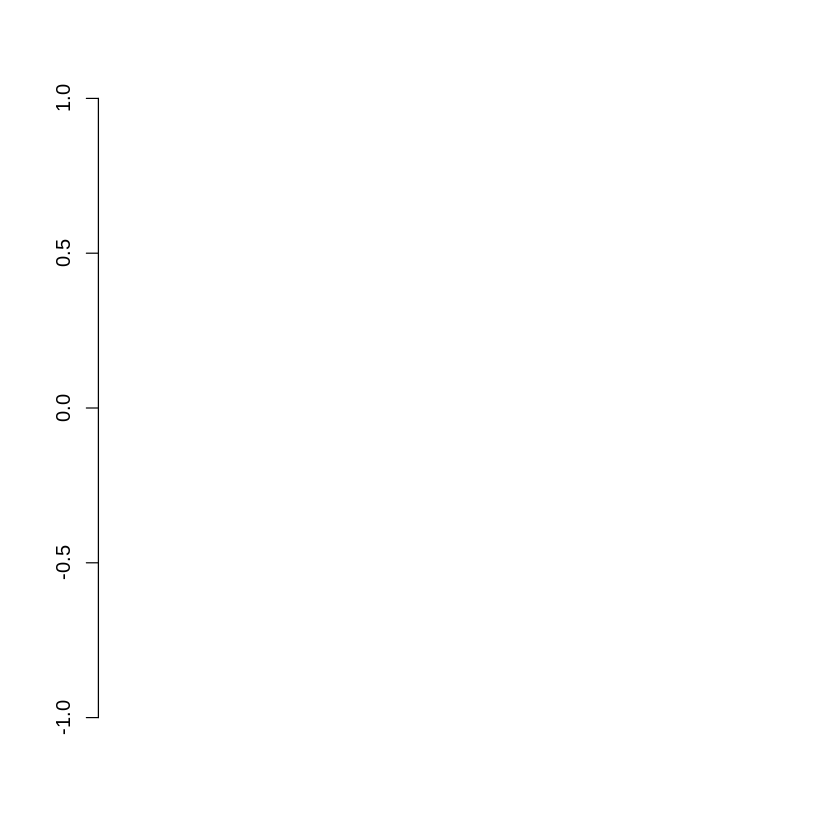

In [92]:
barplot(Proporcion_explicada)

In [91]:
var_cp / sum(var_cp)

[1] 1.414377e-01 1.139666e-01 9.513900e-02 5.512932e-02 3.582853e-02
  [6] 2.621184e-02 1.704685e-02 1.404809e-02 1.321574e-02 9.167074e-03
 [11] 8.714156e-03 8.697350e-03 7.993180e-03 7.854994e-03 7.774335e-03
 [16] 7.617427e-03 7.572833e-03 7.335598e-03 7.205071e-03 7.055127e-03
 [21] 6.914082e-03 6.749410e-03 6.662264e-03 6.562193e-03 6.429669e-03
 [26] 6.313476e-03 6.273629e-03 6.125222e-03 5.991783e-03 5.937302e-03
 [31] 5.890990e-03 5.790804e-03 5.656346e-03 5.614782e-03 5.573299e-03
 [36] 5.442287e-03 5.368603e-03 5.243138e-03 5.158087e-03 5.021452e-03
 [41] 5.015219e-03 4.976503e-03 4.922901e-03 4.809318e-03 4.756861e-03
 [46] 4.748599e-03 4.666103e-03 4.578122e-03 4.477114e-03 4.402106e-03
 [51] 4.355699e-03 4.245650e-03 4.152881e-03 4.047316e-03 4.031708e-03
 [56] 3.937253e-03 3.908322e-03 3.853894e-03 3.776381e-03 3.735405e-03
 [61] 3.687341e-03 3.659967e-03 3.614634e-03 3.573318e-03 3.490029e-03
 [66] 3.474177e-03 3.380962e-03 3.367563e-03 3.316966e-03 3.283456e-03
 [71] 3.246160e-03 3.227211e-03 3.139829e-03 3.095410e-03 3.041935e-03
 [76] 3.016468e-03 2.966197e-03 2.929481e-03 2.896432e-03 2.887226e-03
 [81] 2.832329e-03 2.819239e-03 2.778750e-03 2.704573e-03 2.671344e-03
 [86] 2.640068e-03 2.620280e-03 2.613629e-03 2.531758e-03 2.487694e-03
 [91] 2.454873e-03 2.444196e-03 2.399650e-03 2.372186e-03 2.345014e-03
 [96] 2.302146e-03 2.289265e-03 2.247569e-03 2.182372e-03 2.168718e-03
[101] 2.147060e-03 2.116735e-03 2.099270e-03 2.053913e-03 2.002978e-03
[106] 1.978943e-03 1.934002e-03 1.920160e-03 1.878528e-03 1.858723e-03
[111] 1.841860e-03 1.805431e-03 1.764633e-03 1.749947e-03 1.738762e-03
[116] 1.712078e-03 1.693169e-03 1.652533e-03 1.648682e-03 1.618831e-03
[121] 1.584968e-03 1.550106e-03 1.534743e-03 1.499639e-03 1.488728e-03
[126] 1.472549e-03 1.440340e-03 1.397498e-03 1.371125e-03 1.304822e-03
[131] 1.277903e-03 1.249043e-03 1.232812e-03 1.216170e-03 1.195446e-03
[136] 1.178515e-03 1.136647e-03 1.110500e-03 1.095363e-03 1.079219e-03
[141] 1.063733e-03 1.036333e-03 1.018368e-03 9.888450e-04 9.751048e-04
[146] 9.259456e-04 9.027169e-04 8.850057e-04 8.646783e-04 8.354080e-04
[151] 8.257344e-04 8.061804e-04 7.627979e-04 7.512528e-04 7.340078e-04
[156] 7.121553e-04 7.018828e-04 6.460953e-04 6.040063e-04 2.293313e-15
[161] 1.294475e-15 1.700203e-15 8.942408e-16 6.374973e-16 3.627890e-16
[166] 2.265175e-16 3.115581e-16 4.037650e-16 5.074498e-16 1.981211e-16
[171] 2.561795e-16 1.624584e-16 1.553781e-16 1.769275e-16 1.965963e-16
[176] 1.370604e-16 1.462013e-16 1.168318e-16 1.541067e-16 1.874110e-16
[181] 1.740627e-16 2.254530e-16 1.311204e-16 1.151296e-16 1.241938e-16
[186] 1.783214e-16 1.154994e-16 1.638961e-16 1.396589e-16 1.544712e-16
[191] 1.717739e-16 1.383262e-16 1.166943e-16 1.116561e-16 1.556422e-16
[196] 1.160728e-16 1.341532e-16 1.566710e-16 1.507628e-16 1.385343e-16
[201] 1.363478e-16 1.548479e-16 1.459887e-16 1.996769e-16 1.527844e-16
[206] 1.281107e-16 1.564632e-16 1.502730e-16 1.830755e-16 2.158495e-16
[211] 1.420986e-16 1.490701e-16 1.060159e-16 1.793535e-16 1.872911e-16
[216] 1.441144e-16 1.211681e-16 1.299624e-16 2.097261e-16 1.667810e-16
[221] 1.452932e-16 1.297797e-16 1.834155e-16 1.461979e-16 1.402529e-16
[226] 1.333280e-16 1.329537e-16 1.559407e-16 1.814251e-16 1.343360e-16
[231] 1.929723e-16 2.531701e-16 1.361966e-16 1.172417e-16 2.474083e-16
[236] 1.339726e-16 1.339190e-16 1.362538e-16 1.290310e-16 1.331677e-16
[241] 1.632326e-16 1.149427e-16 1.900383e-16 1.421826e-16 1.430183e-16
[246] 1.396316e-16 1.593233e-16 1.682606e-16 1.550062e-16 1.197845e-16
[251] 1.141528e-16 1.754647e-16 1.416531e-16 1.554704e-16 2.839002e-16
[256] 1.318561e-16 1.373313e-16 1.188715e-16 1.332576e-16 1.467076e-16
[261] 1.498470e-16 3.091978e-16 1.439700e-16 1.134863e-16 1.530578e-16
[266] 1.545335e-16 1.429200e-16 1.771435e-16 1.405090e-16 2.247788e-16
[271] 4.029045e-16 1.319746e-16 2.994410e-16 1.403545e-16 1.533935e-16
[276] 1.843306e-16 1.615590e-16 1.960904e-16 1.267104e-16 1.257615e-16
[281] 1.356260e-16 1.56948

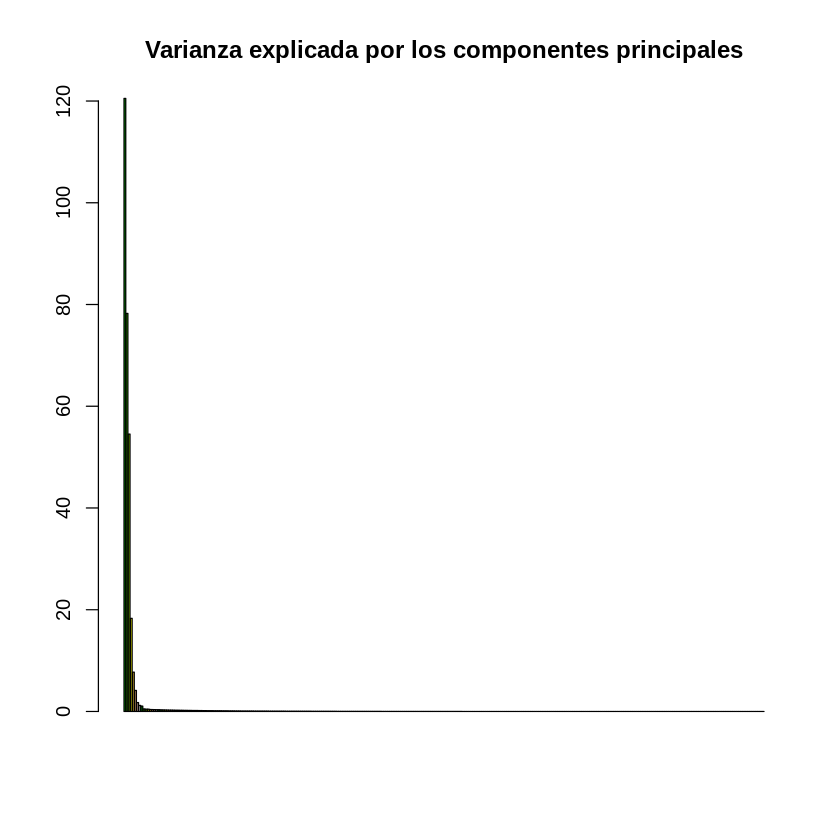

In [86]:
# estimo las varianzas de los estimadores de los autovectores y 
# armo una tabla para tener una primera idea 
# de si algun autovalor podria llegar a ser igual que otro

s_lambda<-lambda*sqrt(2/43)
tabla<-rbind(lambda,s_lambda)
row.names(tabla) <- c("Lambda_pico", "s_Lambda")
colnames(tabla)  <- paste("V", 1:301, sep= "")

#Es decir,
#• podemos pensar que la segunda componente est ́a bien determinada, o
#sea, que λ3 es distinto a  λ2 y
#• quiz ́as dudemos sobre la tercera o sea, no podemos asegurar todav ́ıa que
#λ3 es distinto a λ4.

# desvíos standard de los componentes principales
var_cp<-apply(v,1,sd)
barplot(var_cp^2, main = "Varianza explicada por los componentes principales",
       col=terrain.colors(8))


# que es lo mismo que...
#barplot(sqrt(lambda), main = "Varianza explicada por los componentes principales", 
#        col=terrain.colors(8))



In [87]:
tabla

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301
Lambda_pico,120.51365,78.24584,54.52846,18.309281,7.733287,4.1390538,1.7506300,1.1888879,1.0521772,0.5062529,...,-4.839244e-16,-5.082427e-16,-5.298613e-16,-5.920393e-16,-7.361766e-16,-8.883952e-16,-8.943731e-16,-1.28543e-15,-1.493673e-15,-8.646786e-15
s_Lambda,25.99064,16.87493,11.75991,3.948681,1.667804,0.8926513,0.3775506,0.2564022,0.2269184,0.1091813,...,-1.043658e-16,-1.096104e-16,-1.142728e-16,-1.276825e-16,-1.587679e-16,-1.915962e-16,-1.928855e-16,-2.77223e-16,-3.221339e-16,-1.864814e-15
